# MediaPipe Landmark & Feature Exploration

This notebook tries to visually explore the preprocessed How2Sign landmark data for ablation studies.

**Data schema reminder:**
- `landmarks_image`: `(T, 128, 3)` — normalized image coordinates  
- `landmarks_world`: `(T, 128, 3)` — world coordinates  
- `features_geometric`: `(T, 36)` — compact geometric features  
- `valid_mask`: `(T, 128)` — per-landmark detection mask  
- `timestamps_ms`: `(T,)` — frame timestamps  
- `handedness_scores`: `(T, 2)` — left/right confidence

**Landmark blocks:**
| Block | Indices | Count |
|-------|---------|-------|
| Pose | 0:33 | 33 |
| Left hand | 33:54 | 21 |
| Right hand | 54:75 | 21 |
| ASL face subset | 75:128 | 53 |

## 0. Setup & Configuration

In [43]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import ipywidgets as widgets

# Dataset root 
DATA_ROOT = Path("data/how2sign_landmarks")

# Landmark block slices
BLOCKS = {
    "pose":       (slice(0,  33),  "#4C72B0", "Pose (33 pts)"),
    "left_hand":  (slice(33, 54),  "#DD8452", "Left Hand (21 pts)"),
    "right_hand": (slice(54, 75),  "#55A868", "Right Hand (21 pts)"),
    "face":       (slice(75, 128), "#C44E52", "ASL Face (53 pts)"),
}

# MediaPipe Pose connections (landmark index pairs)
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),          # face
    (9,10),                                                     # mouth
    (11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),   # left arm
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),           # right arm
    (11,23),(12,24),(23,24),                                   # torso
    (23,25),(25,27),(27,29),(29,31),(27,31),                   # left leg
    (24,26),(26,28),(28,30),(30,32),(28,32),                   # right leg
]

# MediaPipe Hand connections (21 landmarks each)
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),             # thumb
    (0,5),(5,6),(6,7),(7,8),             # index
    (0,9),(9,10),(10,11),(11,12),        # middle
    (0,13),(13,14),(14,15),(15,16),      # ring
    (0,17),(17,18),(18,19),(19,20),      # pinky
    (5,9),(9,13),(13,17),                # palm
]

print("✓ Imports OK")

✓ Imports OK


## 1. Load Metadata & Feature Names

In [44]:
metadata = pd.read_parquet("../data/how2sign_landmarks/metadata.parquet")
metadata = metadata[metadata["n_frames"] >= 10].reset_index(drop=True)

with open("../data/how2sign_landmarks/feature_names.json") as f:
    feature_names = json.load(f)["features_geometric"]

print(f"Loaded {len(metadata):,} clips  |  {len(feature_names)} geometric features")
metadata[["sentence_id", "split", "n_frames", "duration", "sentence"]].head()

Loaded 34,756 clips  |  36 geometric features


,sentence_id,split,n_frames,duration,sentence
0,--8pSDeC-fg_0,train,12,0.48,Hi.
1,--8pSDeC-fg_1,train,62,2.58,My name is Dr. Art Bowler.
2,--8pSDeC-fg_10,train,162,6.77,Are you always focused on the positive aspects...
3,--8pSDeC-fg_11,train,88,3.64,If so you have high self esteem.
4,--8pSDeC-fg_12,train,266,11.09,Low self esteem tends to bring us down and the...


## 2. Helpers — Load a Single Clip

In [45]:
def load_clip(row):
    """Return all arrays for a single metadata row."""
    with np.load("../data/how2sign_landmarks/" + row["shard_file"]) as shard:
        key = row["sample_key"]
        return {
            "landmarks_image":    shard[f"{key}__landmarks_image"],
            "landmarks_world":    shard[f"{key}__landmarks_world"],
            "features_geometric": shard[f"{key}__features_geometric"],
            "valid_mask":         shard[f"{key}__valid_mask"],
            "timestamps_ms":      shard[f"{key}__timestamps_ms"],
            "handedness_scores":  shard[f"{key}__handedness_scores"],
        }


def get_clip(row_idx=0, split="train"):
    """Convenience: pick a row by position within a split."""
    rows = metadata[metadata["split"] == split].reset_index(drop=True)
    row = rows.iloc[row_idx]
    clip = load_clip(row)
    return row, clip


# Quick smoke-check
row, clip = get_clip(0)
print(f"Sentence : {row['sentence']}")
for k, v in clip.items():
    print(f"  {k:25s}: {v.shape}  dtype={v.dtype}")

Sentence : Hi.
  landmarks_image          : (12, 128, 3)  dtype=float32
  landmarks_world          : (12, 128, 3)  dtype=float32
  features_geometric       : (12, 36)  dtype=float32
  valid_mask               : (12, 128)  dtype=bool
  timestamps_ms            : (12,)  dtype=float32
  handedness_scores        : (12, 2)  dtype=float32


## 3. Dataset Statistics

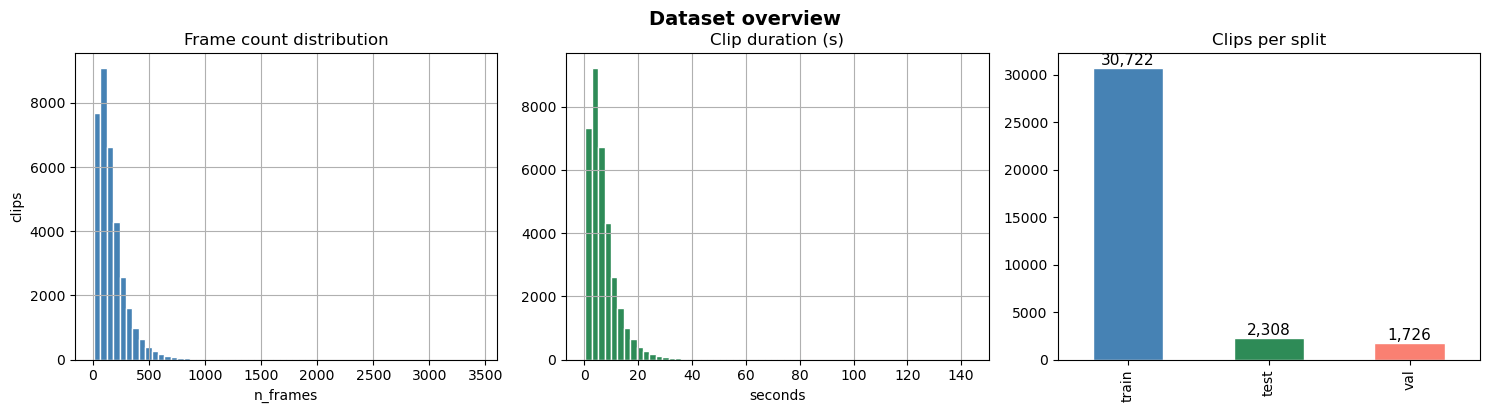

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Frame count distribution
metadata["n_frames"].hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Frame count distribution")
axes[0].set_xlabel("n_frames")
axes[0].set_ylabel("clips")

# Duration distribution
metadata["duration"].hist(bins=60, ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_title("Clip duration (s)")
axes[1].set_xlabel("seconds")

# Split sizes
split_counts = metadata["split"].value_counts()
split_counts.plot.bar(ax=axes[2], color=["steelblue", "seagreen", "salmon"], edgecolor="white")
axes[2].set_title("Clips per split")
axes[2].set_xlabel("")
for p in axes[2].patches:
    axes[2].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.suptitle("Dataset overview", y=1.02, fontsize=14, fontweight="bold")
plt.show()

## 3.5 Choose a Clip

In [48]:
# Re-run this cell to switch the active clip 
# Change row_idx or split to explore different samples.

ROW_IDX = 2      # index within the chosen split
SPLIT   = "train" # 'train' | 'val' | 'test'

row, clip = get_clip(ROW_IDX, split=SPLIT)
T = clip["landmarks_image"].shape[0]
print(f"[{SPLIT}] {row['sentence_id']} | {T} frames | '{row['sentence']}'")

[train] --8pSDeC-fg_10 | 162 frames | 'Are you always focused on the positive aspects of your physical self instead of the negative?'


In [49]:
face_valid = clip["valid_mask"][:, 75:128]
print(f"Face landmarks detected in {face_valid.any(axis=1).sum()} / {face_valid.shape[0]} frames")
print(f"Mean coverage: {face_valid.mean():.3f}")

Face landmarks detected in 162 / 162 frames
Mean coverage: 1.000


## 4. Single-Frame Pose Skeleton

In [ ]:
def draw_pose_frame(ax, lm, valid, frame_width=1280, frame_height=720, alpha=0.8):
    """Draw pose skeleton on ax. lm: (128,3) image coords [0-1]."""
    # Pose skeleton
    pose_lm = lm[0:33]
    for i, j in POSE_CONNECTIONS:
        if valid[i] and valid[j]:
            ax.plot([pose_lm[i,0], pose_lm[j,0]],
                    [pose_lm[i,1], pose_lm[j,1]],
                    color="#4C72B0", lw=1.5, alpha=alpha)
    mask_p = valid[0:33]
    ax.scatter(pose_lm[mask_p,0], pose_lm[mask_p,1],
               c="#4C72B0", s=18, zorder=5, alpha=alpha)

    # Hands
    for (start, color, label), offset in [
            ((33, "#DD8452", "left hand"),  33),
            ((54, "#55A868", "right hand"), 54)]:
        hand_lm = lm[offset:offset+21]
        for i, j in HAND_CONNECTIONS:
            if valid[offset+i] and valid[offset+j]:
                ax.plot([hand_lm[i,0], hand_lm[j,0]],
                        [hand_lm[i,1], hand_lm[j,1]],
                        color=color, lw=1.5, alpha=alpha)
        mask_h = valid[offset:offset+21]
        ax.scatter(hand_lm[mask_h,0], hand_lm[mask_h,1],
                   c=color, s=18, zorder=5, alpha=alpha)

    # Face subset
    face_lm = lm[75:128]
    mask_f  = valid[75:128]
    ax.scatter(face_lm[mask_f,0], face_lm[mask_f,1],
               c="#C44E52", s=8, zorder=5, alpha=alpha*0.7)

    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)
    ax.set_aspect("equal")
    ax.axis("off")


# Interactive widget

def show_frame(frame_idx):
    fig, ax = plt.subplots(figsize=(6, 5))
    lm    = clip["landmarks_image"][frame_idx]
    valid = clip["valid_mask"][frame_idx]
    draw_pose_frame(ax, lm, valid)
    ax.set_title(f"{row['sentence']}\nframe {frame_idx}/{T-1}", fontsize=9)
    handles = [mpatches.Patch(color=c, label=l)
               for _, (_, c, l) in BLOCKS.items()]
    ax.legend(handles=handles, loc="lower right", fontsize=7)
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(value=0, min=0, max=T-1, description="Frame")
widgets.interact(show_frame, frame_idx=slider);

interactive(children=(IntSlider(value=0, description='Frame', max=161), Output()), _dom_classes=('widget-inter…

## 5. Landmark Block Ablation — Toggling Blocks On/Off

In [52]:
def show_ablation_frame(frame_idx, use_pose, use_left_hand, use_right_hand, use_face):
    lm    = clip["landmarks_image"][frame_idx]
    valid = clip["valid_mask"][frame_idx].copy()

    # Zero out blocks that are disabled
    block_flags = {
        "pose":       use_pose,
        "left_hand":  use_left_hand,
        "right_hand": use_right_hand,
        "face":       use_face,
    }
    for name, (slc, color, label) in BLOCKS.items():
        if not block_flags[name]:
            valid[slc] = False

    active = [l for n, (_, _, l) in BLOCKS.items() if block_flags[n]]
    n_pts  = int(valid.sum())

    fig, ax = plt.subplots(figsize=(6, 5))
    draw_pose_frame(ax, lm, valid)
    ax.set_title(f"Active: {', '.join(active) or 'none'}  ({n_pts} pts visible)", fontsize=9)
    plt.tight_layout()
    plt.show()


frame_slider = widgets.IntSlider(value=T//2, min=0, max=T-1, description="Frame")
pose_cb       = widgets.Checkbox(value=True,  description="Pose")
lh_cb         = widgets.Checkbox(value=True,  description="Left Hand")
rh_cb         = widgets.Checkbox(value=True,  description="Right Hand")
face_cb       = widgets.Checkbox(value=True,  description="Face")

widgets.interact(
    show_ablation_frame,
    frame_idx=frame_slider,
    use_pose=pose_cb,
    use_left_hand=lh_cb,
    use_right_hand=rh_cb,
    use_face=face_cb,
)

interactive(children=(IntSlider(value=81, description='Frame', max=161), Checkbox(value=True, description='Pos…

<function __main__.show_ablation_frame(frame_idx, use_pose, use_left_hand, use_right_hand, use_face)>

## 6. Temporal Heatmap of Landmark Activity

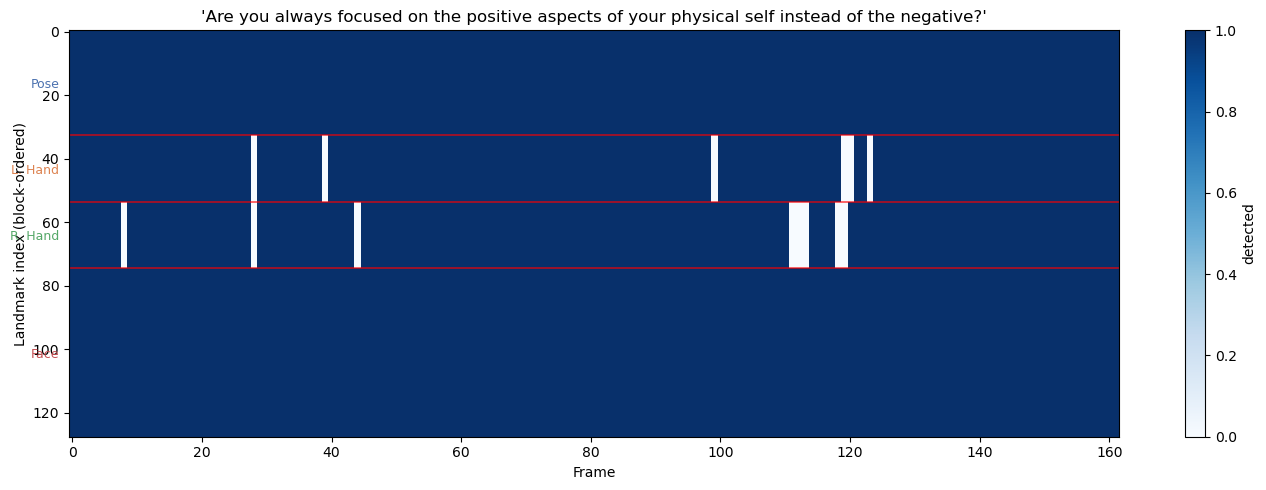

In [53]:
def plot_landmark_activity(clip, title=None):
    """Heatmap of valid_mask over time, grouped by landmark block."""
    valid = clip["valid_mask"] 
    T = valid.shape[0]

    # Reorder landmarks for visual grouping
    block_order = np.concatenate([
        np.arange(0, 33),    # pose
        np.arange(33, 54),   # left hand
        np.arange(54, 75),   # right hand
        np.arange(75, 128),  # face
    ])
    ordered = valid[:, block_order].astype(float).T 

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(ordered, aspect="auto", cmap="Blues",
                   interpolation="nearest", vmin=0, vmax=1)

    # Block dividers + labels
    boundaries = [0, 33, 54, 75, 128]
    block_labels = ["Pose", "L. Hand", "R. Hand", "Face"]
    for b in boundaries[1:-1]:
        ax.axhline(b - 0.5, color="red", lw=1.2, alpha=0.7)
    for k, (start, end, label) in enumerate(zip(boundaries, boundaries[1:], block_labels)):
        ax.text(-2, (start + end) / 2, label,
                ha="right", va="center", fontsize=9, color=list(BLOCKS.values())[k][1])

    ax.set_xlabel("Frame")
    ax.set_ylabel("Landmark index (block-ordered)")
    ax.set_title(title or "Landmark detection mask over time")
    plt.colorbar(im, ax=ax, label="detected")
    plt.tight_layout()
    plt.show()


plot_landmark_activity(clip, title=f"'{row['sentence']}'")

## 7. Geometric Feature Ablation — Compare Feature Subsets Over Time

In [54]:
# Group the 36 geometric features by semantic category
FEATURE_GROUPS = {
    "finger_curl":   [n for n in feature_names if "curl" in n],
    "hand_openness": [n for n in feature_names if "open" in n],
    "wrist_dist":    [n for n in feature_names if "wrist" in n and "dist" in n],
    "two_hand":      [n for n in feature_names if "two_hand" in n or "both" in n],
    "elbow_angle":   [n for n in feature_names if "elbow" in n or "angle" in n],
    "forearm":       [n for n in feature_names if "forearm" in n or "shoulder" in n],
    "mouth_face":    [n for n in feature_names if any(k in n for k in ["mouth", "eye", "face"])],
}
# Catch-all for any ungrouped features
assigned = {f for g in FEATURE_GROUPS.values() for f in g}
FEATURE_GROUPS["other"] = [n for n in feature_names if n not in assigned]

print("Feature groups:")
for g, feats in FEATURE_GROUPS.items():
    print(f"  {g:16s}: {len(feats):2d}  — {feats[:4]}{'...' if len(feats)>4 else ''}")

print(f"\nAll feature names ({len(feature_names)}):")
for i, n in enumerate(feature_names):
    print(f"  [{i:2d}] {n}")

Feature groups:
  finger_curl     : 10  — ['left_thumb_curl', 'left_index_curl', 'left_middle_curl', 'left_ring_curl']...
  hand_openness   :  3  — ['left_hand_openness', 'right_hand_openness', 'mouth_opening']
  wrist_dist      :  1  — ['wrist_distance']
  two_hand        :  0  — []
  elbow_angle     :  2  — ['left_elbow_angle_rad', 'right_elbow_angle_rad']
  forearm         :  6  — ['left_wrist_to_left_shoulder', 'left_wrist_to_right_shoulder', 'right_wrist_to_left_shoulder', 'right_wrist_to_right_shoulder']...
  mouth_face      :  5  — ['left_wrist_to_mouth_center', 'right_wrist_to_mouth_center', 'mouth_opening', 'mouth_width']...
  other           : 10  — ['left_wrist_to_nose', 'left_wrist_to_torso_center', 'right_wrist_to_nose', 'right_wrist_to_torso_center']...

All feature names (36):
  [ 0] left_thumb_curl
  [ 1] left_index_curl
  [ 2] left_middle_curl
  [ 3] left_ring_curl
  [ 4] left_pinky_curl
  [ 5] right_thumb_curl
  [ 6] right_index_curl
  [ 7] right_middle_curl
  [ 8] ri

In [55]:
def plot_feature_group(clip, group_names, feature_names):
    """Plot selected geometric feature groups over time."""
    feats = clip["features_geometric"]
    t = clip["timestamps_ms"] / 1000.0

    selected = []
    for g in group_names:
        selected.extend(FEATURE_GROUPS.get(g, []))
    if not selected:
        print("No features selected.")
        return

    idx = [feature_names.index(n) for n in selected if n in feature_names]
    cols = plt.cm.tab20(np.linspace(0, 1, len(idx)))

    fig, ax = plt.subplots(figsize=(14, 4))
    for i, fi in enumerate(idx):
        ax.plot(t, feats[:, fi], color=cols[i], label=feature_names[fi], lw=1.2)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Feature value")
    ax.set_title(f"Geometric features: {', '.join(group_names)}")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()


# Interactive widget
group_select = widgets.SelectMultiple(
    options=list(FEATURE_GROUPS.keys()),
    value=["finger_curl", "hand_openness"],
    description="Groups",
    layout=widgets.Layout(height="160px")
)
widgets.interact(
    lambda groups: plot_feature_group(clip, list(groups), feature_names),
    groups=group_select
)

interactive(children=(SelectMultiple(description='Groups', index=(0, 1), layout=Layout(height='160px'), option…

<function __main__.<lambda>(groups)>

## 8. Landmarks vs Geometric Features — Side-by-Side Comparison

In [56]:
def side_by_side_frame(frame_idx):
    lm     = clip["landmarks_image"][frame_idx]
    valid  = clip["valid_mask"][frame_idx]
    feats  = clip["features_geometric"][frame_idx]
    t_sec  = clip["timestamps_ms"][frame_idx] / 1000.0

    fig = plt.figure(figsize=(14, 5))
    gs  = GridSpec(1, 2, width_ratios=[1, 1.4], figure=fig)

    # Left — skeleton
    ax_skel = fig.add_subplot(gs[0])
    draw_pose_frame(ax_skel, lm, valid)
    ax_skel.set_title(f"Landmarks  @  {t_sec:.2f}s", fontsize=10)
    handles = [mpatches.Patch(color=c, label=l)
               for _, (_, c, l) in BLOCKS.items()]
    ax_skel.legend(handles=handles, loc="lower right", fontsize=7)

    # Right — geometric features bar
    ax_feat = fig.add_subplot(gs[1])
    bar_colors = plt.cm.RdBu_r((feats + 1) / 2)   # assume roughly -1..1
    ax_feat.barh(range(len(feats)), feats, color=bar_colors, edgecolor="none")
    ax_feat.set_yticks(range(len(feature_names)))
    ax_feat.set_yticklabels(feature_names, fontsize=7)
    ax_feat.axvline(0, color="black", lw=0.8)
    ax_feat.set_xlabel("Feature value")
    ax_feat.set_title("Geometric features (36)", fontsize=10)
    ax_feat.invert_yaxis()

    fig.suptitle(f"'{row['sentence']}'  |  frame {frame_idx}/{T-1}",
                 fontsize=9, y=1.01)
    plt.tight_layout()
    plt.show()


widgets.interact(side_by_side_frame,
                 frame_idx=widgets.IntSlider(value=0, min=0, max=T-1, description="Frame"));

interactive(children=(IntSlider(value=0, description='Frame', max=161), Output()), _dom_classes=('widget-inter…

## 9. Trajectory Plot — Specific Landmark Over Time

In [ ]:
NAMED_LANDMARKS = {
    "nose":          0,
    "left_shoulder": 11,
    "right_shoulder":12,
    "left_wrist":    15,
    "right_wrist":   16,
    "left_pinky":    17,
    "right_pinky":   18,
    "left_index":    19,
    "right_index":   20,
    "lh_wrist":      33,
    "lh_index_tip":  40,
    "rh_wrist":      54,
    "rh_index_tip":  61,
}


def plot_trajectory(landmark_names):
    lm_arr = clip["landmarks_image"]  
    valid  = clip["valid_mask"]      
    t      = clip["timestamps_ms"] / 1000.0

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    axes[0].set_ylabel("x (norm.)")
    axes[1].set_ylabel("y (norm.)")
    axes[1].set_xlabel("Time (s)")
    axes[1].invert_yaxis()

    colors = plt.cm.tab10(np.linspace(0, 1, len(landmark_names)))
    for name, col in zip(landmark_names, colors):
        idx = NAMED_LANDMARKS.get(name, None)
        if idx is None:
            continue
        x = np.where(valid[:, idx], lm_arr[:, idx, 0], np.nan)
        y = np.where(valid[:, idx], lm_arr[:, idx, 1], np.nan)
        axes[0].plot(t, x, label=name, color=col, lw=1.5)
        axes[1].plot(t, y, color=col, lw=1.5)

    axes[0].legend(loc="upper right", fontsize=8)
    axes[0].set_title(f"Landmark trajectories — '{row['sentence']}'")
    plt.tight_layout()
    plt.show()


lm_select = widgets.SelectMultiple(
    options=list(NAMED_LANDMARKS.keys()),
    value=["left_wrist", "right_wrist", "lh_index_tip", "rh_index_tip"],
    description="Landmarks",
    layout=widgets.Layout(height="180px")
)
widgets.interact(lambda lm: plot_trajectory(list(lm)), lm=lm_select);

interactive(children=(SelectMultiple(description='Landmarks', index=(3, 4, 10, 12), layout=Layout(height='180p…

## 10. Input Modality Comparison: `landmarks`, `geometric`, `landmarks+geometric`

In [58]:
def build_input(clip, modality, landmark_blocks=None, geometric_groups=None):
    """
    Build the model input array for a given ablation configuration.

    Parameters
    ----------
    modality : 'landmarks' | 'geometric' | 'landmarks+geometric'
    landmark_blocks : list of block names to keep, e.g. ['pose','left_hand','right_hand']
                      None → keep all blocks
    geometric_groups : list of group names to keep, e.g. ['finger_curl','hand_openness']
                       None → keep all groups

    Returns
    -------
    np.ndarray  shape (T, D)
    """
    parts = []

    if modality in ("landmarks", "landmarks+geometric"):
        lm = clip["landmarks_image"].copy()    # (T, 128, 3)
        valid = clip["valid_mask"].copy()       # (T, 128)
        blocks_to_keep = landmark_blocks or list(BLOCKS.keys())
        keep_mask = np.zeros(128, dtype=bool)
        for b in blocks_to_keep:
            slc, _, _ = BLOCKS[b]
            keep_mask[slc] = True
        lm[:, ~keep_mask, :] = 0
        valid[:, ~keep_mask] = False
        parts.append(lm.reshape(lm.shape[0], -1))   # (T, 128*3)

    if modality in ("geometric", "landmarks+geometric"):
        fg = clip["features_geometric"].copy()   # (T, 36)
        groups_to_keep = geometric_groups or list(FEATURE_GROUPS.keys())
        keep_feats = []
        for g in groups_to_keep:
            keep_feats.extend(FEATURE_GROUPS.get(g, []))
        feat_idx = [feature_names.index(n) for n in keep_feats if n in feature_names]
        parts.append(fg[:, feat_idx] if feat_idx else np.zeros((fg.shape[0], 0)))

    return np.concatenate(parts, axis=1) if parts else np.empty((clip["timestamps_ms"].shape[0], 0))


# Summary table of all three modalities
for mod in ("landmarks", "geometric", "landmarks+geometric"):
    arr = build_input(clip, mod)
    print(f"{mod:25s}  shape={arr.shape}  D={arr.shape[1]}")

landmarks                  shape=(162, 384)  D=384
geometric                  shape=(162, 37)  D=37
landmarks+geometric        shape=(162, 421)  D=421


In [64]:
def summarize_ablation(clip, modality, landmark_blocks=None, geometric_groups=None):
    arr = build_input(clip, modality, landmark_blocks, geometric_groups)
    T, D = arr.shape
    mean_act = np.nanmean(np.abs(arr))
    temporal_var = np.nanvar(arr, axis=0).mean()
    nonzero  = np.count_nonzero(arr) / arr.size if arr.size > 0 else 0
    return {"T": T, "D": D, "mean_abs": float(mean_act), "temporal_var": float(temporal_var), "nonzero_ratio": float(nonzero)}


# Compare all landmark-block ablations
from itertools import chain, combinations

block_names = list(BLOCKS.keys())
all_combos  = list(chain.from_iterable(
    combinations(block_names, r) for r in range(1, len(block_names)+1)
))

rows_out = []
for combo in all_combos:
    s = summarize_ablation(clip, "landmarks", landmark_blocks=list(combo))
    s["blocks"] = "+".join(combo)
    rows_out.append(s)

df_abl = pd.DataFrame(rows_out)[["blocks", "D", "mean_abs", "temporal_var", "nonzero_ratio"]]
df_abl.style.background_gradient(subset=["mean_abs", "temporal_var"], cmap="Blues")

,blocks,D,mean_abs,temporal_var,nonzero_ratio
0,pose,384,0.145900,0.000535,0.257812
1,left_hand,384,0.063031,0.000570,0.164062
2,right_hand,384,0.055129,0.000460,0.164062
3,face,384,0.122222,0.000014,0.414062
4,pose+left_hand,384,0.209823,0.001105,0.421875
5,pose+right_hand,384,0.202221,0.000996,0.421875
6,pose+face,384,0.268122,0.000550,0.671875
7,left_hand+right_hand,384,0.119018,0.001030,0.328125
8,left_hand+face,384,0.186000,0.000584,0.578125
9,right_hand+face,384,0.178349,0.000475,0.578125


## 11. Validity Coverage Across Multiple Clips

/tmp/ipykernel_353002/3952241607.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


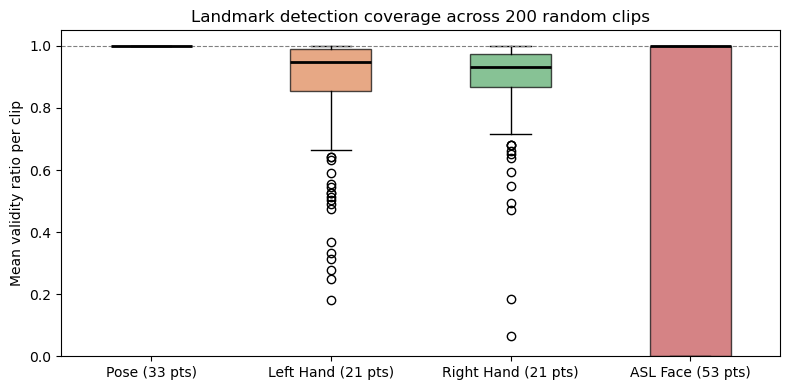

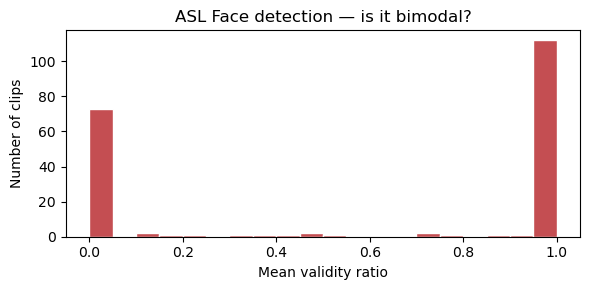

In [65]:
N_SAMPLE = 200
rng = np.random.default_rng(42)
sample_idx = rng.integers(0, len(metadata), size=N_SAMPLE)

coverage = {b: [] for b in BLOCKS}
for i in sample_idx:
    row_s = metadata.iloc[i]
    try:
        c = load_clip(row_s)
        valid = c["valid_mask"]  # (T, 128)
        for name, (slc, _, _) in BLOCKS.items():
            coverage[name].append(valid[:, slc].mean())
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(
    [coverage[b] for b in BLOCKS],
    labels=[BLOCKS[b][2] for b in BLOCKS],
    patch_artist=True,
    medianprops=dict(color="black", lw=2),
)
colors = [BLOCKS[b][1] for b in BLOCKS]
for patch, col in zip(bp["boxes"], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.set_ylabel("Mean validity ratio per clip")
ax.set_title(f"Landmark detection coverage across {N_SAMPLE} random clips")
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(coverage["face"], bins=20, color="#C44E52", edgecolor="white")
ax.set_xlabel("Mean validity ratio")
ax.set_ylabel("Number of clips")
ax.set_title("ASL Face detection — is it bimodal?")
plt.tight_layout()
plt.show()